# Session 4: Heart Rate Analysis

In [1]:
# Importing Functions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [3]:
# Naming empty lists

In [4]:
time = []
absorption = []

In [5]:
# Load absorption data from CSV file

In [6]:
with open('data/pulse_data.csv', 'r') as f:
    next(f)
    
    for line in f:
        t, p = line.strip().split(',')
        time.append(float(t))
        absorption.append(float(p))

In [7]:
# Convert to numpy

In [8]:
time = np.array(time)
absorption = np.array(absorption)

In [9]:
# Plot pulse data over time using matplotlib

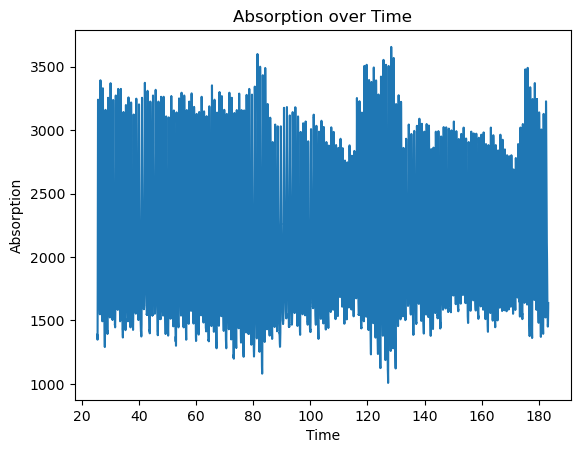

In [10]:
plt.plot(time, absorption)
plt.xlabel("Time")
plt.ylabel("Absorption")
plt.title("Absorption over Time")
plt.show()

In [11]:
# Peak Detection

##Peaks correspond to heart beats and are identified as local maxima in the absorption signal.

##Using NumPy arrays allows efficient vectorized comparison of neighboring values to detect peaks.

##A minimum time separation between consecutive peaks is enforced to ensure that detected peaks represent physiological heart beats rather than noise.

In [12]:
# Peak Detection

In [13]:
from scipy.signal import find_peaks

# --- Peak detection using scipy ---

# calculate sampling rate
sampling_interval = time[1] - time[0]
sampling_rate = 1 / sampling_interval

# minimum distance between peaks (0.5 sec)
min_distance = int(0.5 * sampling_rate)

# detect peaks
peak_indices, _ = find_peaks(
    absorption,
    distance=200,  
    prominence=300  
)

# convert to time
peaks = time[peak_indices]

print("Number of peaks:", len(peaks))

Number of peaks: 180


In [14]:
# Detect local peaks in the absorption signal
# A peak is defined as a point that is greater than its immediate neighbors.
# This creates a boolean mask identifying all local maxima.

In [15]:
delta_t = np.diff(peaks)

In [16]:
# Heart Rate Calculation

#The heart rate is calculated using:

# H = 60 / ΔT

# where ΔT is the time between peaks.

In [17]:
time_diff = np.diff(peaks)

heart_rate = 60 / time_diff

In [18]:
# Heart Rate Plot

# We plot the heart rate over time.

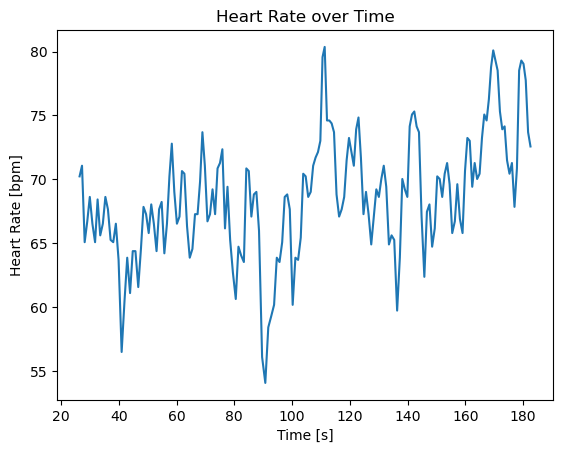

In [19]:
plt.figure()

plt.plot(peaks[1:], heart_rate)

plt.xlabel("Time [s]")
plt.ylabel("Heart Rate [bpm]")
plt.title("Heart Rate over Time")

plt.show()

In [20]:
#Peak Detection Shown in Plots

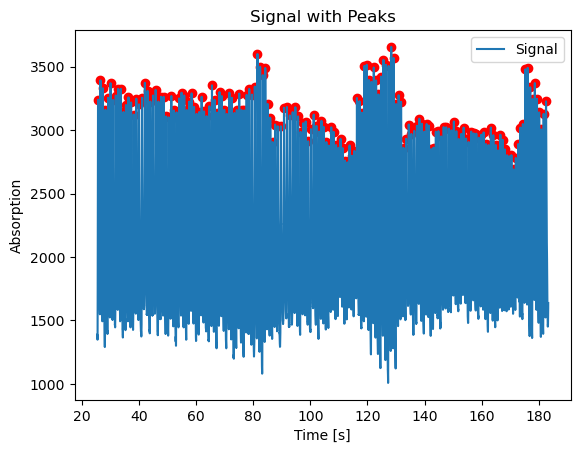

In [21]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(time, absorption, label="Signal")
plt.scatter(time[peak_indices], absorption[peak_indices], color='red')

plt.xlabel("Time [s]")
plt.ylabel("Absorption")
plt.legend()
plt.title("Signal with Peaks")
plt.show()

In [22]:
print("time differences:", time_diff[:10])
print("heart rate sample:", heart_rate[:10])


time differences: [0.85433966 0.84431808 0.92198533 0.89943677 0.87438282 0.90194217
 0.92198533 0.87688822 0.91446914 0.90194217]
heart rate sample: [70.22967863 71.06326532 65.07695765 66.70841341 68.61982926 66.52311226
 65.07695765 68.42377261 65.61183675 66.52311226]
